<a href="https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/punpy_with_errcorr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Training Session - CoMet Toolkit: Uncertainties made easy**

# Exercise X: From spectrometer measurements to NDVI with uncertainty propagation.

## Background
In the lab session, repeated spectrometer measurements were taken of:
- astro turf
- cress
- sand
- a Spectralon reference panel

All targets were illuminated using the same lamp.

The Spectralon panel has a known reflectance, so it can be used to convert digital numbers (DNs) measured by the spectrometer into surface reflectance:

$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

In this exercise, we will:
1. Calculate reflectance spectra for astro turf, cress and sand.
2. Propagate uncertainties from repeated measurements and panel reflectance using [**punpy**](https://punpy.readthedocs.io/en/latest/).
3. Integrate the spectra with red and NIR spectral response functions (SRFs).
4. Calculate NDVI.
5. Compare the NDVI values and uncertainties for the three surfaces.

## Learning objectives
By the end of this exercise, you should be able to:
- define a measurement model in Python
- estimate random uncertainty from repeated measurements
- include a systematic uncertainty term from Spectralon reflectance
- use punpy to propagate uncertainty through a multi-step calculation
- calculate NDVI from band-integrated reflectances
- compare NDVI values with uncertainties for different surfaces

## *Step 1* - Set up the environment

First, we again install the punpy package for uncertainty propagation.

In [1]:
!pip install punpy>=1.0.6

Please hit `Runtime > Restart Session` to properly load these packages into your Google Colab environment...

Then, import the relevant python packages required in this training:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import punpy
import xarray as xr
import os

❗Note: If this import fails, it is likely because the pip installation has not properly updated in the Google colab session. Please restart session (in runtime tab above).

## *Step 2* - Load and Inspect the Measurement Data

The dataset contains repeated spectromter measuremetnts from 600 - 1000 nm for:
   - Spectralon (for calibration purposes)
   - Astro turf
   - Cress
   - Sand

Each target has several (25-75) repeats.

In [29]:
# Load datasets from NetCDF files
# this_directory = os.path.dirname(os.path.abspath(__file__))
data_dir = "example_data"

spectralon_ds = xr.open_dataset(os.path.join(data_dir, "Spectralon.nc"))
astroturf_ds = xr.open_dataset(os.path.join(data_dir, "Astro_turf.nc"))
cress_ds = xr.open_dataset(os.path.join(data_dir, "Cress.nc"))
sand_ds = xr.open_dataset(os.path.join(data_dir, "Sand.nc"))

# Extract wavelengths and digital number (DN) data
wavelength = spectralon_ds['wavelength'].values

dn_panel_repeats = spectralon_ds['digital_number'].values / spectralon_ds.attrs['integration_time_ms']      # shape: (n_wavelength, n_panel_repeats)
dn_astroturf_repeats = astroturf_ds['digital_number'].values / astroturf_ds.attrs['integration_time_ms']     # shape: (n_wavelength, n_astroturf_repeats)
dn_cress_repeats = cress_ds['digital_number'].values / cress_ds.attrs['integration_time_ms']             # shape: (n_wavelength, n_cress_repeats)
dn_sand_repeats = sand_ds['digital_number'].values / sand_ds.attrs['integration_time_ms']               # shape: (n_wavelength, n_sand_repeats)

# Placeholder for Spectralon reflectance data
rho_panel = np.ones(wavelength.shape[0])             # shape: (n_wavelength,)
u_rho_panel = 0.01*np.ones(wavelength.shape[0])           # shape: (n_wavelength,)

print("Wavelength shape:", wavelength.shape)
print("Panel repeats:", dn_panel_repeats.shape)
print("Astro-turf repeats:", dn_astroturf_repeats.shape)
print("Cress repeats:", dn_cress_repeats.shape)
print("Sand repeats:", dn_sand_repeats.shape)

Wavelength shape: (1718,)
Panel repeats: (1718, 25)
Astro-turf repeats: (1718, 51)
Cress repeats: (1718, 77)
Sand repeats: (1718, 60)


### Inspect the repeated measurements
First, calculate the mean and standard deviation of the repeated DN measurements for each target.
The standard deviation of repeated measurements will be used to estimate the random measurement noise.

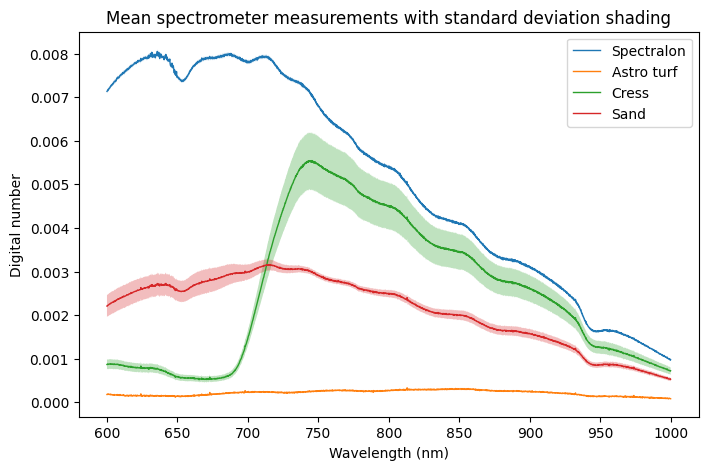

In [30]:
def calculate_stats(dn_repeats):
    """Calculate mean and standard deviation across repeats for each band."""
    mean = np.mean(dn_repeats, axis=1)
    std = np.std(dn_repeats, axis=1, ddof=1)
    return mean, std

# Calculate mean and std for each target
dn_panel_mean, dn_panel_std = calculate_stats(dn_panel_repeats)
dn_astroturf_mean, dn_astroturf_std = calculate_stats(dn_astroturf_repeats)
dn_cress_mean, dn_cress_std = calculate_stats(dn_cress_repeats)
dn_sand_mean, dn_sand_std = calculate_stats(dn_sand_repeats)

# Plot the DN measurement data with shaded uncertainty regions
plt.figure(figsize=(8, 5))
plt.plot(wavelength, dn_panel_mean, label="Spectralon", linewidth=1)
plt.fill_between(wavelength, dn_panel_mean - dn_panel_std, dn_panel_mean + dn_panel_std, alpha=0.3)

plt.plot(wavelength, dn_astroturf_mean, label="Astro turf", linewidth=1)
plt.fill_between(wavelength, dn_astroturf_mean - dn_astroturf_std, dn_astroturf_mean + dn_astroturf_std, alpha=0.3)

plt.plot(wavelength, dn_cress_mean, label="Cress", linewidth=1)
plt.fill_between(wavelength, dn_cress_mean - dn_cress_std, dn_cress_mean + dn_cress_std, alpha=0.3)

plt.plot(wavelength, dn_sand_mean, label="Sand", linewidth=1)
plt.fill_between(wavelength, dn_sand_mean - dn_sand_std, dn_sand_mean + dn_sand_std, alpha=0.3)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Digital number")
plt.title("Mean spectrometer measurements with standard deviation shading")
plt.legend()
plt.show()

For this exercise, we consider two main sources of uncertainty:
### Random uncertainty
- repeatability of the DN measurements for the surface
- repeatability of the DN measurements for the Spectralon panel
### Systematic uncertainty
- uncertainty in the Spectralon reflectance

These uncertainty sources affect the reflectance calculation, and will then propagate into the red and NIR band reflectances and finally into NDVI.

## *Step 3* - Define the Measurement Functions

We will use three models:

1. **Surface reflectance** from surface DN, panel DN and panel reflectance:

$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

2. **Band-integrated reflectance** from a reflectance spectrum and an SRF:

$$\rho_{\text{band}} = \frac{\int \rho(\lambda) \cdot \text{SRF}(\lambda) \, d\lambda}{\int \text{SRF}(\lambda) \, d\lambda}$$

3. **NDVI** from red and NIR band reflectances:

$$\text{NDVI} = \frac{\rho_{\text{NIR}} - \rho_{\text{red}}}{\rho_{\text{NIR}} + \rho_{\text{red}}}$$

In [31]:
def reflectance_model(dn_surface, dn_panel, rho_panel):
   return (dn_surface / dn_panel) * rho_panel

def band_integrate(rho_spectrum, srf):
   pass # placeholder for now - will implement later but will be integration of rho_specturm over SRF

def ndvi_model(rho_red, rho_nir):
   return (rho_nir - rho_red) / (rho_nir + rho_red)

## *Step 4* - Calculate the Reflectance Spectra for each Target

In [32]:
rho_astroturf = reflectance_model(dn_astroturf_mean, dn_panel_mean, rho_panel)
rho_cress = reflectance_model(dn_cress_mean, dn_panel_mean, rho_panel)
rho_sand = reflectance_model(dn_sand_mean, dn_panel_mean, rho_panel)

## *Step 4* - Propagate Uncertainties to the Reflectance Spectra

In [33]:
prop = punpy.MCPropagation(10000)

u_random_rho_astroturf = prop.propagate_random(
   reflectance_model,
   [dn_astroturf_mean, dn_panel_mean, rho_panel],
   [dn_astroturf_std, dn_panel_std, None]
)
u_syst_rho_astroturf = prop.propagate_systematic(
    reflectance_model,
        [dn_astroturf_mean, dn_panel_mean, rho_panel],
        [None, None, u_rho_panel]
)
print("Random uncertainty for Astro turf:", u_random_rho_astroturf)
print("Systematic uncertainty for Astro turf:", u_syst_rho_astroturf)
# print("Total uncertainty for Astro turf:", u_rho_astroturf)
u_random_rho_cress = prop.propagate_random(
   reflectance_model,
    [dn_cress_mean, dn_panel_mean, rho_panel],
    [dn_cress_std, dn_panel_std, None]
)
u_syst_rho_cress = prop.propagate_systematic(
    reflectance_model,
     [dn_cress_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

u_random_rho_sand = prop.propagate_random(
   reflectance_model,
    [dn_sand_mean, dn_panel_mean, rho_panel],
    [dn_sand_std, dn_panel_std, None]
)
u_syst_rho_sand = prop.propagate_systematic(
    reflectance_model,
     [dn_sand_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

Random uncertainty for Astro turf: [0.00223324 0.00220295 0.00231105 ... 0.01021361 0.01132091 0.01180625]
Systematic uncertainty for Astro turf: [0.000243   0.00025588 0.00025232 ... 0.00085044 0.0008306  0.00081396]


In [34]:
# Calculate total uncertainty by combining random and systematic components
u_rho_astroturf = np.sqrt(u_random_rho_astroturf**2 + u_syst_rho_astroturf**2)
u_rho_cress = np.sqrt(u_random_rho_cress**2 + u_syst_rho_cress**2)
u_rho_sand = np.sqrt(u_random_rho_sand**2 + u_syst_rho_sand**2)

In [44]:
# Define a helper function to plot spectra with uncertainty
def plot_spectrum_with_uncertainty(wavelength, rho, u_rho, label, ax=None):
   if ax is None:
      fig, ax = plt.subplots(figsize=(6, 3))
      show_plot = True
   else:
      show_plot = False
   
   ax.plot(wavelength, rho, label=label, linewidth=2)
   ax.fill_between(wavelength, rho - u_rho, rho + u_rho, alpha=0.3)
   ax.set_xlabel("Wavelength (nm)")
   ax.set_ylabel("Reflectance")
   ax.legend()
   
   if show_plot:
      ax.set_title(f"{label} reflectance with uncertainty")
      plt.show()

def plot_uncertainty_components(wavelength, u_random, u_syst, label, ax=None):
   if ax is None:
      fig, ax = plt.subplots(figsize=(6, 3))
      show_plot = True
   else:
      show_plot = False

   ax.plot(wavelength, u_random, label="Random uncertainty", linestyle='--', linewidth=0.7)
   ax.plot(wavelength, u_syst, label="Systematic uncertainty", linestyle='--', linewidth=0.7)
   ax.plot(wavelength, np.sqrt(u_random**2 + u_syst**2), label="Total uncertainty", linewidth=0.7)
   ax.set_xlabel("Wavelength (nm)")
   ax.set_ylabel("Uncertainty in reflectance")
   ax.set_title(f"Uncertainty components for {label}")
   ax.legend()
   if show_plot:
      plt.show()

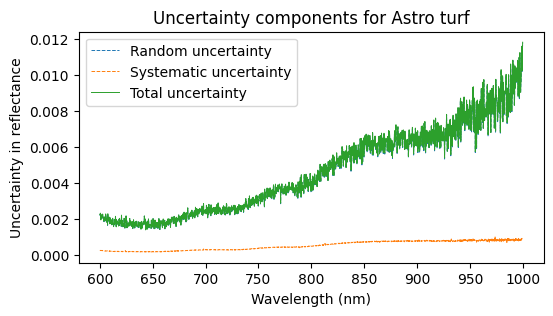

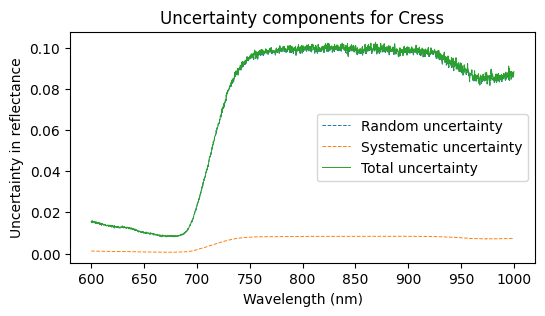

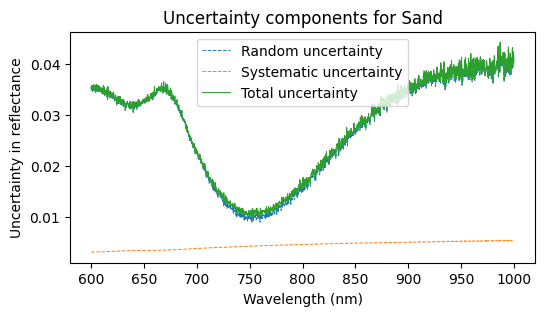

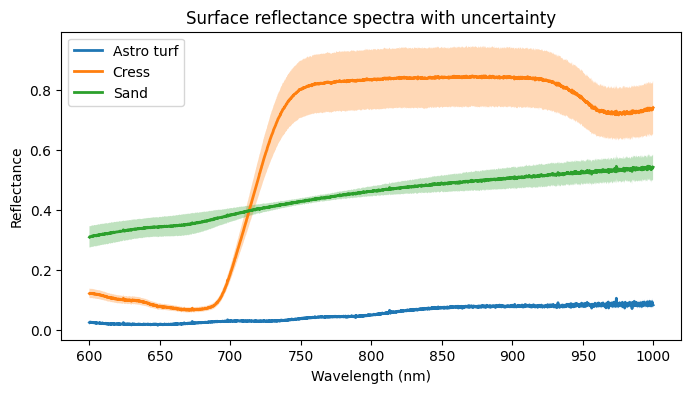

In [ ]:
# Plot uncertainty components for each target as subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_uncertainty_components(wavelength, u_random_rho_astroturf, u_syst_rho_astroturf, "Astro turf", ax=axes[0])
plot_uncertainty_components(wavelength, u_random_rho_cress, u_syst_rho_cress, "Cress", ax=axes[1])
plot_uncertainty_components(wavelength, u_random_rho_sand, u_syst_rho_sand, "Sand", ax=axes[2])
fig.suptitle("Uncertainty components for each surface")
plt.tight_layout()
plt.show()

# Plot spectra with uncertainty for each target
fig, ax = plt.subplots(figsize=(8, 4))
plot_spectrum_with_uncertainty(wavelength, rho_astroturf, u_rho_astroturf, "Astro turf", ax=ax)
plot_spectrum_with_uncertainty(wavelength, rho_cress, u_rho_cress, "Cress", ax=ax)
plot_spectrum_with_uncertainty(wavelength, rho_sand, u_rho_sand, "Sand", ax=ax)
ax.set_title("Surface reflectance spectra with uncertainty")
plt.show()

## *Step 4* - Integrate over Red and NIR Spectral Response Functions, and Propagate Uncertainties

## *Step 4* - Calculate NDVI and Propagate Uncertainties

## *Step 4* - Visualise and Compare NDVI Values with Uncertainties

## *Optional Extension* - End-to-End Measurement Function

The entire processing chain (spectrometer-measured DN → reflectance spectra $\rho(\lambda)$ → red and NIR band reflectances $\rho_{\text{red}}$, $\rho_{\text{NIR}}$ → NDVI) can be combined into a single end-to-end measurement function. This approach allows uncertainties to be propagated in one step, rather than at each intermediate stage.

**Benefits:**
- Simplified uncertainty propagation workflow
- All correlations between intermediate steps are automatically captured
- More efficient computation for complex processing chains

**Try it yourself:** Write a single measurement function that takes the raw DN measurements and returns the final NDVI, incorporating all three models presented above.

In [ ]:
# Define your end-to-end measurement function here
# This function should take raw DN measurements as input and return NDVI as output

def end_to_end_ndvi(dn_surface, dn_panel, rho_panel, rho_spectrum, srf_red, srf_nir):
    """
    Calculate NDVI from raw spectrometer measurements in one step.
    
    Parameters:
    -----------
    dn_surface : array-like
        Surface measurement digital numbers
    dn_panel : array-like
        Panel measurement digital numbers
    rho_panel : array-like
        Panel reflectance spectrum
    rho_spectrum : array-like
        Reflectance spectrum of the surface
    srf_red : array-like
        Red band spectral response function
    srf_nir : array-like
        NIR band spectral response function
        
    Returns:
    --------
    ndvi : float
        Normalized Difference Vegetation Index
    """
    # TODO: Implement the end-to-end function
    pass

In [ ]:
# Propagate uncertainties through the end-to-end measurement function
# TODO: Initialize a punpy propagation object and apply the end_to_end_ndvi function
# to calculate NDVI with uncertainty propagation

# Consider which uncertainty sources should be included:
# - Random uncertainties from DN measurements
# - Systematic uncertainties from panel reflectance
# - Any other relevant uncertainty components

# Steps:
# 1. Create a punpy propagation object (e.g., MCPropagation with appropriate number of samples)
# 2. Call the propagation method with end_to_end_ndvi and your input data with uncertainties
# 3. Compare the results with the step-by-step propagation approach

ndvi_e2e = None  # Replace with your propagation result
ndvi_e2e_unc = None  # Replace with uncertainty estimate

## *Step 2* - Define measurement function and input data

In this exercise, our aim is to get familiar with the basic functionality for dealing with error correlation in punpy. We will use the same example as in exercise 1 using a very basic sensor calibration, where we have some digital numbers for the signal (referred to as L0) and the gains (typically obtained from a lab calibration) to convert these to a physical quantity (referred to as L1). E.g., this could be a radiance measurement collected by an in-situ instrument.  

First, we define our measurement function. For use in punpy, this measurement function needs to be written as a Python function that takes the input quantities (on which we have uncertainties available) as arguments and the measurand (to which we want to propagate the uncertainties) as return. For some further information on measurement functions, input quantities and measurand, see the [CoMet webpage](https://www.comet-toolkit.org/user-guide/theory/).

In [ ]:
# your measurement function
def calibrate(L_grass, E_lamp):
   return np.pi * L_grass / E_lamp

Here, the measurement function is a very simple analytical function. However, in practice, this measurement function can contain as much complexity (including calls to other packages/external software, ...) as needed. To some extent, the measurement function is treated as a black box, as long as the measurand and input quantities are structured as expected.

Next, we define some example input data. For your own use case, you need to have this information available from other sources (i.e. the input uncertainties need to be understood prior to using punpy). We here now separate random and systematic uncertainties (though the total adds up to the same uncertainties as in exercise 1).

In [ ]:
# your data
wavs = np.array([350,450,550,650,750])
L0 = np.array([0.43,0.8,0.7,0.65,0.9])
gains = np.array([23,26,28,29,31])

# your uncertainties
L0_ur = L0*0.05                             # 5% random uncertainty
L0_us = np.ones(5)*0.03                     # systematic uncertainty of 0.03

gains_ur = np.array([0.5,0.7,0.6,0.4,0.1])  # random uncertainty
gains_us = np.array([0.1,0.2,0.1,0.4,0.3])  # systematic uncertainty


## *Step 3* - Propagate the random and systematic uncertainties

After defining the data, the resulting uncertainty budget can then be calculated with punpy using the Monte Carlo (MC) method. First, we propagate the random and systematic uncertainties separately, and then combine the resulting L1 uncertainties. 

In [ ]:
# initialise a punpy MCpropagation object with 10000 MC samples
prop=punpy.MCPropagation(10000)

# apply the measuremnet function to calculate the measurand from the input quantities
L1=calibrate(L0,gains)

# propagate random uncertainties
# The format for the inputs is propagate_random(measurement function, [list of function inputs], [list of uncertainties in the same order of inputs])
L1_ur=prop.propagate_random(calibrate,[L0,gains],
      [L0_ur,gains_ur])

# propagate systematic uncertainties
L1_us=prop.propagate_systematic(calibrate,[L0,gains],
      [L0_us,gains_us])

# combine random and systematic uncertainties
L1_ut=(L1_ur**2+L1_us**2)**0.5


# print the results
print("L1:", L1)
print("L1_ur:", L1_ur)
print("L1_us:", L1_us)
print("L1_ut:", L1_ut)

To know the error correlation of the total uncertainties, we need to sum the covariance of the random and systematic uncertainties. The error correlations can be converted to error covariance and back using some helper functions.

In [ ]:
# define error correlation for random and systematic uncertainties
L1_rand_err_corr=np.eye(len(L1_ur))                     # random uncertainties have an identity matrix as the error correlation
L1_sys_err_corr=np.ones((len(L1_us),len(L1_us)))             # systematic uncertainties have a matrix full of ones as the error correlation

# calculate random and systematic error covariance matrices 
L1_rand_cov=punpy.convert_corr_to_cov(L1_rand_err_corr,L1_ur)
L1_sys_cov=punpy.convert_corr_to_cov(L1_sys_err_corr,L1_us)

# combine random and systematic error covariance matrices and calculate the total error correlation matrix
L1_cov=L1_rand_cov + L1_sys_cov
L1_corr=punpy.correlation_from_covariance(L1_cov)

print("L1_cov:\n",L1_cov)
print("L1_corr:\n",L1_corr)

We can then plot and inspect the results:

In [ ]:
# define plot to show results
def make_plots_L1(L1,L1_ur=None,L1_us=None,L1_ut=None,L1_corr=None):
  if L1_cov is not None:
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
  else:
    fig,ax1 = plt.subplots(1,figsize=(5,5))

  ax1.plot(wavs,L1,"o")
  if L1_ur is not None:
    ax1.errorbar(wavs,L1,yerr=L1_ur,label="random uncertainty",capsize=5)
  if L1_us is not None:
    ax1.errorbar(wavs,L1,yerr=L1_us,label="systematic uncertainty",capsize=5)
  if L1_ut is not None:
    ax1.errorbar(wavs,L1,yerr=L1_ut,label="total uncertainty",capsize=5)
  ax1.legend()
  ax1.set_xlabel("wavelength (nm)")
  ax1.set_ylabel("radiance")
  ax1.set_title("L1 uncertainties")
  if L1_cov is not None:
    ax2.set_title("L1 correlation")
    cov_plot=ax2.imshow(L1_corr)
    plt.colorbar(cov_plot,ax=ax2)
  plt.show()
make_plots_L1(L1,L1_ur,L1_us,L1_ut,L1_corr) # make and display plot

## *Step 4* - Why does error correlation matter?

The results in the previous step were identical to those in exercise 1, so why does it matter what the error correlation is? Any time we are combining measurements and want to know the uncertainties on the resulting output, the error correlations do play an important role. For example if we are averaging data and assume the total uncertainties have a random error correlation (as in exercise 1):

In [ ]:
L1_avg=np.mean(L1)
print("L1 average:", L1_avg)
L1_avg_ut = prop.propagate_random(np.mean,[L1],
      [L1_ut])
print("L1 average uncertainty:", L1_avg_ut)

However if we use the error correlation we calculated in the previous example:


In [ ]:
L1_avg_ur = prop.propagate_random(np.mean,[L1],
      [L1_ur])
print("L1 average random uncertainty:", L1_avg_ur)
L1_avg_us = prop.propagate_systematic(np.mean,[L1],
      [L1_us])
print("L1 average systematic uncertainty:", L1_avg_us)
L1_avg_ut_errcorr = (L1_avg_ur**2 + L1_avg_us**2)**0.5
print("L1 average total uncertainty (errcorr):", L1_avg_ut_errcorr)

Note that this is now different to the previous answer. Without correctly taking into account the error correlation, we would have significantly underestimated the uncertainties. 

## *Step 5* - Propagate uncertainties with an error correlation matrix

Instead of separately propagating the random and systematic uncertainties, we can also achieve the same result by first combining the random and systematic uncertainties on the input, and then propagating the total uncertainties and their error correlation. In this case, the error correlation needs to be explicitly passed to the `propagate_standard' function.

In [ ]:
# first combine the random and systemtic uncertainties on the inputs
L0_ut=(L0_ur**2+L0_us**2)**0.5
gains_ut=(gains_ur**2+gains_us**2)**0.5

# combine the error correlation matrices on the inputs (by combining the error covariances)
L0_cov=punpy.convert_corr_to_cov(np.eye(len(L0_ur)),L0_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(L0_us),len(L0_us))),L0_us)
L0_corr=punpy.correlation_from_covariance(L0_cov)

gains_cov=punpy.convert_corr_to_cov(np.eye(len(gains_ur)),gains_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(gains_us),len(gains_us))),gains_us)
gains_corr=punpy.correlation_from_covariance(gains_cov)

# propagate the combined uncertainties and error correlation
L1_ut, L1_corr=prop.propagate_standard(calibrate,[L0,gains],
      [L0_ut,gains_ut],[L0_corr,gains_corr], return_corr=True)

# propagate the average and its uncertainty using the previously determined error correlation
L1_avg_ut_errcorr = prop.propagate_standard(np.mean,[L1],
      [L1_ut],[L1_corr])


# print results
print("L1:", L1)
print("L1_ut:", L1_ut)
print("L1_corr:\n", L1_corr)
print("L1 average total uncertainty (errcorr):", L1_avg_ut_errcorr)
make_plots_L1(L1,L1_ut=L1_ut,L1_corr=L1_corr)

## **Exercise**

Let's again add an additional variable to the measurement function, and propagate uncertainties.
Either propagate the random and systematic uncertainties separately and combine them at the end, or combine them first.
Here is the updated measurement function with the additional input data:

In [ ]:
# updated measurement function
def calibrate(L0,gains,dark):
   return (L0-dark)*gains

# additional input quantity
dark = np.array([0.05,0.03,0.04,0.05,0.06])
dark_ur = np.array([0.02,0.02,0.02,0.02,0.02])  # random uncertainty

Try this yourself: propagate the uncertainties through this measurement function, based on the examples above. (❗Note: there are no systematic uncertainties on the darks, set them to zero if required).

In [ ]:
# Enter your code here

## *Step 6* - Error correlation between variables

In addition to having a correlation along one or more dimensions of a given variable, it is also possible that two variables are correlated (for example because they are measured using the same sensor). This can be specified in punpy by using the corr_between keyword. In the example below, the systematic errors in the darks and L0 data are fully correlated.

In [ ]:
# We here define some systematic uncertainties for the darks, which are the same as for the digital numbers
dark_us = L0_us

# We then define how the errors for the different variables are correlated
corr_var=np.array([[1,0,1],   # here a 1 means the variables are fully correlated, and a 0 means uncorrelated
                   [0,1,0],   # on the diagonal there are 1's because each variable is fully correlated with itself
                   [1,0,1]])  # there are also 1's on the (0,2) and (2,0) locations, indicating the 1st and last variable (i.e. L0 and dark) are correlated 

# We then recalculate the uncertainties and make a plot
L1_ur=prop.propagate_random(calibrate,[L0,gains,dark],
      [L0_ur,gains_ur,dark_ur])
L1_us=prop.propagate_systematic(calibrate,[L0,gains,dark],
      [L0_us,gains_us,L0_us],corr_between=corr_var)

L1_ut=(L1_ur**2+L1_us**2)**0.5

L1_cov=punpy.convert_corr_to_cov(np.eye(len(L1_ur)),L1_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(L1_us),len(L1_us))),L1_us)
L1_corr=punpy.correlation_from_covariance(L1_cov)

L1_avg_ut_errcorr = prop.propagate_standard(np.mean,[L1],
      [L1_ut],[L1_corr])

make_plots_L1(L1,L1_ur,L1_us,L1_ut,L1_corr)

## *Step 7* - Punpy keywords

There are many keywords that can be passed to the punpy functions to control the detailed behaviour. For a detailed description refer to the [punpy documentation](https://punpy.readthedocs.io/en/latest/content/generated/punpy.mc.mc_propagation.MCPropagation.propagate_standard.html). An additional features we would like to highlight is the ability to return the individual MC samples that were used, for manual inspection:

In [ ]:
L1_ut, L1_corr, MCsamples_L1, MCsamples_L0=prop.propagate_standard(calibrate,[L0,gains,dark],
      [L0_ut,gains_ut,dark_ur],[L0_corr,gains_corr,"rand"], return_corr=True, return_samples=True)  # the return_samples keyword is set to True
print("MC samples L0:", MCsamples_L0)
print("MC samples L1:", MCsamples_L1)

In these dark samples, there are some negative values. Depending on the use case, this might be considered unphysical.

Furthermore, it is possible to use different probability density functions (PDF) instead of the default Gaussian PDF. E.g., it is possible to define a lower boundary for the values in the MCsamples of the inputs, and thus avoid negative outputs:

In [ ]:
L1_ut, MCsamples_L1, MCsamples_L0 = prop.propagate_standard(calibrate,[L0,gains,dark],
      [L0_ut,gains_ut,dark_ur],[L0_corr,gains_corr,"rand"], return_corr=False, return_samples=True, pdf_shape="truncated_gaussian", pdf_params={"min":0.})  # the pdf shape is set to truncated gaussian, and pdf_param is a dictionary that allows to set the minimum and maximum value
print("MC samples L0:", MCsamples_L0)
print("MC samples L1:", MCsamples_L1)

This version has no negative values. (❗Note: this does artificially reduce the uncertainties, so use with caution!)